# Задание 2. Методы линейной регрессии и их сравнение

#### 1. Загрузка датасета и вывод на экран

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy.typing import NDArray
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

Array = NDArray[np.float64]


def load_data(path: str | Path) -> pd.DataFrame:
    return pd.read_csv(path)


data = load_data("auto_dataset.csv")
data.head()

,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
0,volkswagen,golf,kleinwagen,manuell,benzin,nein,75,150000,177,1500
1,skoda,fabia,kleinwagen,manuell,diesel,nein,69,90000,93,3600
2,bmw,3er,limousine,manuell,benzin,ja,102,150000,246,650
3,peugeot,2_reihe,cabrio,manuell,benzin,nein,109,150000,140,2200
4,mazda,3_reihe,limousine,manuell,benzin,nein,105,150000,136,2000


#### 2. Разбиение датасета на train, val, test в соотношении 8:1:1

In [2]:
TARGET = "price"
CAT_FEATURES = ["brand", "model", "vehicleType", "gearbox", "fuelType", "notRepairedDamage"]
NUM_FEATURES = ["powerPS", "kilometer", "autoAgeMonths"]


def split_data(
    data: pd.DataFrame,
    *,
    train_sz: float = 0.8,
    val_sz: float = 0.1,
    random_state: int = 67,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_df, temp_df = train_test_split(
        data,
        train_size=train_sz,
        random_state=random_state,
    )

    val_df, test_df = train_test_split(
        temp_df,
        train_size=val_sz / (1.0 - train_sz),
        random_state=random_state,
    )
    return (train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True))


train_df, val_df, test_df = split_data(data)
print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)

Train: (800, 10)
Val:   (100, 10)
Test:  (100, 10)


#### Вывод первых строк каждой выборки на экран

In [3]:
print("Train")
print(train_df.head())
print("Val")
print(val_df.head())
print("Test")
print(test_df.head())

Train
           brand     model vehicleType    gearbox fuelType notRepairedDamage  \
0     volkswagen      golf   limousine    manuell   benzin              nein   
1        porsche       911       coupe  automatik   benzin              nein   
2           audi        a6       kombi    manuell   benzin              nein   
3  mercedes_benz  e_klasse       kombi  automatik   diesel              nein   
4            bmw       1er       coupe  automatik   benzin              nein   

   powerPS  kilometer  autoAgeMonths  price  
0       75     150000            137   3499  
1      301     150000            220  17500  
2      209     100000            108  13990  
3      170     150000            114   3500  
4      306      40000             75  26500  
Val
        brand   model vehicleType  gearbox fuelType notRepairedDamage  \
0         bmw     5er   limousine  manuell   benzin              nein   
1  volkswagen  andere      andere  manuell   diesel              nein   
2      toyota 

#### 2. Кодирование категориальных признаков для всех выборок

Это необходимо сделать, чтобы перевести все словесные характеристики в числа для будущего обучения.

In [4]:
def add_bias(X: Array) -> Array:
    return np.c_[np.ones(X.shape[0], dtype=np.float64), X]


def encode_features(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    cat_features: list[str],
    num_features: list[str],
    target: str,
) -> tuple[Array, Array, Array, Array, Array, Array, ColumnTransformer]:
    encoder = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_features),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features),
        ],
    )
    X_train = add_bias(np.asarray(encoder.fit_transform(train_df), dtype=np.float64))
    X_val = add_bias(np.asarray(encoder.transform(val_df), dtype=np.float64))
    X_test = add_bias(np.asarray(encoder.transform(test_df), dtype=np.float64))
    y_train = np.asarray(train_df[target], dtype=np.float64)
    y_val = np.asarray(val_df[target], dtype=np.float64)
    y_test = np.asarray(test_df[target], dtype=np.float64)
    return X_train, X_val, X_test, y_train, y_val, y_test, encoder


X_train, X_val, X_test, y_train, y_val, y_test, encoder = encode_features(
    train_df,
    val_df,
    test_df,
    CAT_FEATURES,
    NUM_FEATURES,
    TARGET,
)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "y_test: ", y_test.shape)

X_train: (800, 200) y_train: (800,)
X_val:   (100, 200) y_val:   (100,)
X_test:  (100, 200) y_test:  (100,)


#### 3. Исследование VanillaGradientDescent

1. Для каждого шага lyamda в логарифмической сетке: 10^-5, … , 1:

обучите VanillaGradientDescent с шагом lyamda на train, вычисляем R^2_train и Loss_train;

протестируйте VanillaGradientDescent с шагом lyamda на val, вычисляем Loss_val.

2. Найдите наилучший шаг lyamda по минимальному Loss_val.

In [5]:
LAMBDA_GRID = np.logspace(-5, 2, 8, dtype=np.float64)
MAX_ITER = 3_000
TOL = 1e-4

In [6]:
class BaseLinearDescent:
    def __init__(
        self,
        lambda_: float,
        *,
        s0: float = 1.0,
        p: float = 0.5,
        max_iter: int = MAX_ITER,
        tol: float = TOL,
        random_state: int = 42,
    ) -> None:
        self.lambda_ = lambda_
        self.s0 = s0
        self.p = p
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.weights_: Array | None = None
        self.train_loss_history: list[float] = []
        self.val_loss_history: list[float] = []

    def _lr(self, k: int) -> float:
        return float(self.lambda_ * (self.s0 / (self.s0 + k)) ** self.p)

    def predict(self, X: Array) -> Array:
        if self.weights_ is None:
            raise RuntimeError("Модель ещё не обучена.")
        return X @ self.weights_

    def loss(self, X: Array, y: Array) -> float:
        return mean_squared_error(y, self.predict(X))

    @property
    def n_iter(self) -> int:
        return len(self.train_loss_history)

    def _record(self, X: Array, y: Array, X_val: Array, y_val: Array, w: Array) -> float:
        train_loss = mean_squared_error(y, X @ w)
        self.train_loss_history.append(train_loss)
        self.val_loss_history.append(mean_squared_error(y_val, X_val @ w))
        return train_loss

    def _step(self, X: Array, y: Array, w: Array, k: int, rng: np.random.Generator) -> Array:
        raise NotImplementedError

    def fit(self, X: Array, y: Array, X_val: Array, y_val: Array) -> BaseLinearDescent:
        n_features = X.shape[1]
        w = np.zeros(n_features, dtype=np.float64)
        self.train_loss_history = []
        self.val_loss_history = []
        rng = np.random.default_rng(self.random_state)
        prev = np.inf
        for k in range(self.max_iter):
            loss = self._record(X, y, X_val, y_val, w)
            if not np.isfinite(loss):
                break
            if k > 0 and abs(prev - loss) < self.tol * max(abs(loss), 1.0):
                break
            prev = loss
            w = self._step(X, y, w, k, rng)
            if not np.isfinite(w).all():
                break
        self.weights_ = w
        return self

In [7]:
def mse_gradient(X: Array, y: Array, w: Array) -> Array:
    return 2.0 / X.shape[0] * X.T @ (X @ w - y)


def score(model: BaseLinearDescent, X: Array, y: Array) -> tuple[float, float]:
    pred = model.predict(X)
    if not np.isfinite(pred).all():
        return float("inf"), float("-inf")
    return float(mean_squared_error(y, pred)), float(r2_score(y, pred))


def tune_lambda(
    descent_cls: type[BaseLinearDescent],
    X_train: Array,
    y_train: Array,
    X_val: Array,
    y_val: Array,
    lambda_grid: Array = LAMBDA_GRID,
) -> tuple[pd.DataFrame, BaseLinearDescent]:
    models: list[BaseLinearDescent] = []
    rows: list[dict[str, float]] = []

    with np.errstate(over="ignore", invalid="ignore"):
        for lambda_ in lambda_grid:
            model = descent_cls(float(lambda_)).fit(X_train, y_train, X_val, y_val)
            loss_train, r2_train = score(model, X_train, y_train)
            loss_val, _ = score(model, X_val, y_val)
            models.append(model)
            rows.append(
                {
                    "lambda": model.lambda_,
                    "loss_train": loss_train,
                    "r2_train": r2_train,
                    "loss_val": loss_val,
                    "n_iter": model.n_iter,
                }
            )

    table = pd.DataFrame(rows)
    return table, models[int(table["loss_val"].idxmin())]


def collect_metrics(
    model: BaseLinearDescent,
    X_train: Array,
    y_train: Array,
    X_test: Array,
    y_test: Array,
) -> dict[str, float]:
    loss_train, r2_train = score(model, X_train, y_train)
    loss_test, r2_test = score(model, X_test, y_test)
    return {
        "lambda": model.lambda_,
        "loss_train": loss_train,
        "loss_test": loss_test,
        "r2_train": r2_train,
        "r2_test": r2_test,
        "n_iter": model.n_iter,
    }


def print_summary(
    name: str,
    model: BaseLinearDescent,
    X_train: Array,
    y_train: Array,
    X_test: Array,
    y_test: Array,
) -> None:
    metrics = collect_metrics(model, X_train, y_train, X_test, y_test)
    print(name)
    print(f"  лучший шаг: {metrics['lambda']:g}")
    print(f"  Loss train: {metrics['loss_train']:.2f}")
    print(f"  Loss test:  {metrics['loss_test']:.2f}")
    print(f"  R^2 train:  {metrics['r2_train']:.4f}")
    print(f"  R^2 test:   {metrics['r2_test']:.4f}")
    print(f"  итераций:   {metrics['n_iter']:.0f}")


def plot_val_history(name: str, model: BaseLinearDescent) -> None:
    plt.figure(figsize=(8, 4))  # type: ignore
    plt.plot(model.val_loss_history)
    plt.yscale("log")
    plt.title(f"{name}: Loss val при λ = {model.lambda_:g}")
    plt.xlabel("итерация")
    plt.ylabel("Loss val")
    plt.grid(True)
    plt.tight_layout()
    plt.show()  # type: ignore

In [8]:
class VanillaGradientDescent(BaseLinearDescent):
    def _step(self, X: Array, y: Array, w: Array, k: int, rng: np.random.Generator) -> Array:
        return w - self._lr(k) * mse_gradient(X, y, w)


vanilla_table, vanilla_best = tune_lambda(VanillaGradientDescent, X_train, y_train, X_val, y_val)
vanilla_table

,lambda,loss_train,r2_train,loss_val,n_iter
0,0.00001,1.178431e+08,-0.781649,5.606228e+07,2
1,0.00010,1.166242e+08,-0.763220,5.520958e+07,59
2,0.00100,6.320000e+07,0.044491,2.135200e+07,2533
3,0.01000,2.431792e+07,0.632342,9.224470e+06,1156
4,0.10000,2.053794e+07,0.689491,1.144732e+07,334
5,1.00000,1.635538e+07,0.752726,1.256095e+07,647
6,10.00000,inf,-inf,2.560715e+305,174
7,100.00000,inf,-inf,inf,72


#### 4. Тестирование VanillaGradientDescent с лучшим шагом

Выведите (R_test)^2 и Loss_test.

In [9]:
vanilla_loss_test, vanilla_r2_test = score(vanilla_best, X_test, y_test)
print(f"Лучший шаг: {vanilla_best.lambda_:g}")
print(f"Loss test:  {vanilla_loss_test:.2f}")
print(f"R^2 test:   {vanilla_r2_test:.4f}")

Лучший шаг: 0.01
Loss test:  19968808.42
R^2 test:   0.6679


#### 5. Вывод по VanillaGradientDescent

1. Выведите на экран: лучший шаг, loss_train (для лучшего шага), loss_test, r^2_train (для лучшего шага), число итераций на val;

2. Отобразите график зависимости Loss_val для лучшего шага от числа итераций.

VanillaGradientDescent
  лучший шаг: 0.01
  Loss train: 24317916.17
  Loss test:  19968808.42
  R^2 train:  0.6323
  R^2 test:   0.6679
  итераций:   1156


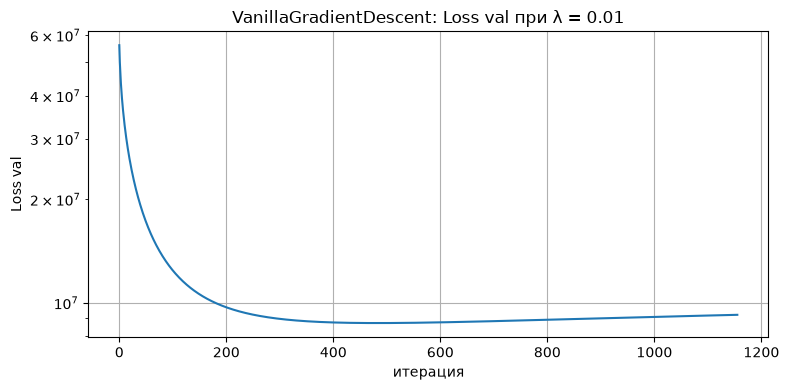

In [10]:
print_summary("VanillaGradientDescent", vanilla_best, X_train, y_train, X_test, y_test)
plot_val_history("VanillaGradientDescent", vanilla_best)

#### 6. Исследование StochasticGradientDescent

1. Для каждого шага lyamda в логарифмической сетке: 10^-5, … , 1:

обучите StochasticGradientDescent с шагом lyamda на train, вычислите R_train ^ 2 и Loss_train;

протестируйте StochasticGradientDescent с шагом lyamda на val, вычислите Loss_val.

2. Найдите лучший шаг lyamda по минимальному Loss_val.

In [11]:
class StochasticGradientDescent(BaseLinearDescent):
    batch_size: int = 32

    def _step(self, X: Array, y: Array, w: Array, k: int, rng: np.random.Generator) -> Array:
        batch = rng.choice(X.shape[0], size=self.batch_size, replace=False)
        return w - self._lr(k) * mse_gradient(X[batch], y[batch], w)


sgd_table, sgd_best = tune_lambda(StochasticGradientDescent, X_train, y_train, X_val, y_val)
sgd_table

,lambda,loss_train,r2_train,loss_val,n_iter
0,0.00001,1.178419e+08,-0.781630,5.606162e+07,2
1,0.00010,1.168758e+08,-0.767023,5.538178e+07,40
2,0.00100,8.402958e+07,-0.270428,3.351836e+07,620
3,0.01000,3.642642e+07,0.449276,9.776867e+06,181
4,0.10000,2.189351e+07,0.668996,1.034715e+07,93
5,1.00000,1.945869e+10,-293.192297,1.763217e+10,137
6,10.00000,inf,-inf,5.487948e+305,174
7,100.00000,inf,-inf,inf,72


#### 7. Тестирование StochasticGradientDescent с лучшим шагом

Выведите (R_test)^2 и Loss_test.

In [12]:
sgd_loss_test, sgd_r2_test = score(sgd_best, X_test, y_test)
print(f"Лучший шаг: {sgd_best.lambda_:g}")
print(f"Loss test:  {sgd_loss_test:.2f}")
print(f"R^2 test:   {sgd_r2_test:.4f}")

Лучший шаг: 0.01
Loss test:  31617363.23
R^2 test:   0.4742


#### 8. Вывод по StochasticGradientDescent

1. Выведите на экран: лучший шаг, loss_train (для лучшего шага), loss_test, r^2_train (для лучшего шага), число итераций на val;

2. Отобразите график зависимости Loss_val для лучшего шага от числа итераций.

StochasticGradientDescent
  лучший шаг: 0.01
  Loss train: 36426422.09
  Loss test:  31617363.23
  R^2 train:  0.4493
  R^2 test:   0.4742
  итераций:   181


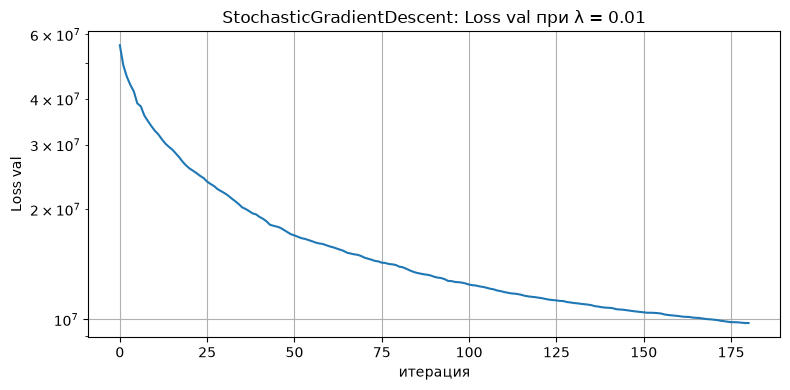

In [13]:
print_summary("StochasticGradientDescent", sgd_best, X_train, y_train, X_test, y_test)
plot_val_history("StochasticGradientDescent", sgd_best)

#### 9. Исследование SAGDescent

1. Для каждого шага lyamda в логарифмической сетке: 10^-5, … , 1:

обучите SAGDescent с шагом lyamda на train, вычисляем R^2_train и Loss_train;

протестируйте SAGDescent с шагом lyamda на val, вычисляем Loss_val.

2. Найдите наилучший шаг lyamda по минимальному Loss_val.

In [14]:
class SAGDescent(BaseLinearDescent):
    _residuals: Array
    _mean_grad: Array

    def _step(self, X: Array, y: Array, w: Array, k: int, rng: np.random.Generator) -> Array:
        n_samples = X.shape[0]
        if k == 0:
            self._residuals = np.zeros(n_samples, dtype=np.float64)
            self._mean_grad = np.zeros(X.shape[1], dtype=np.float64)
        j = int(rng.integers(n_samples))
        residual = 2.0 * (float(X[j] @ w) - y[j])
        self._mean_grad = self._mean_grad + (residual - self._residuals[j]) / n_samples * X[j]
        self._residuals[j] = residual
        return w - self._lr(k) * self._mean_grad


sag_table, sag_best = tune_lambda(SAGDescent, X_train, y_train, X_val, y_val)
sag_table

,lambda,loss_train,r2_train,loss_val,n_iter
0,0.00001,1.178521e+08,-7.817838e-01,5.606854e+07,2
1,0.00010,1.178521e+08,-7.817836e-01,5.606852e+07,2
2,0.00100,1.178519e+08,-7.817810e-01,5.606837e+07,2
3,0.01000,1.178502e+08,-7.817555e-01,5.606680e+07,2
4,0.10000,2.975755e+07,5.501011e-01,1.409540e+07,198
5,1.00000,1.358990e+08,-1.054632e+00,9.961337e+07,138
6,10.00000,5.105684e+07,2.280810e-01,2.838230e+07,12
7,100.00000,2.201593e+26,-3.328548e+18,1.738265e+26,677


#### 10. Тестирование SAGDescent с лучшим шагом

Выведите (R_test)^2 и Loss_test.

In [15]:
sag_loss_test, sag_r2_test = score(sag_best, X_test, y_test)
print(f"Лучший шаг: {sag_best.lambda_:g}")
print(f"Loss test:  {sag_loss_test:.2f}")
print(f"R^2 test:   {sag_r2_test:.4f}")

Лучший шаг: 0.1
Loss test:  26724223.16
R^2 test:   0.5555


#### 11. Вывод по SAGDescent

1. Выведите на экран: лучший шаг, loss_train (для лучшего шага), loss_test, r^2_train (для лучшего шага), число итераций на val;

2. Отобразите график зависимости Loss_val для лучшего шага от числа итераций.

SAGDescent
  лучший шаг: 0.1
  Loss train: 29757546.88
  Loss test:  26724223.16
  R^2 train:  0.5501
  R^2 test:   0.5555
  итераций:   198


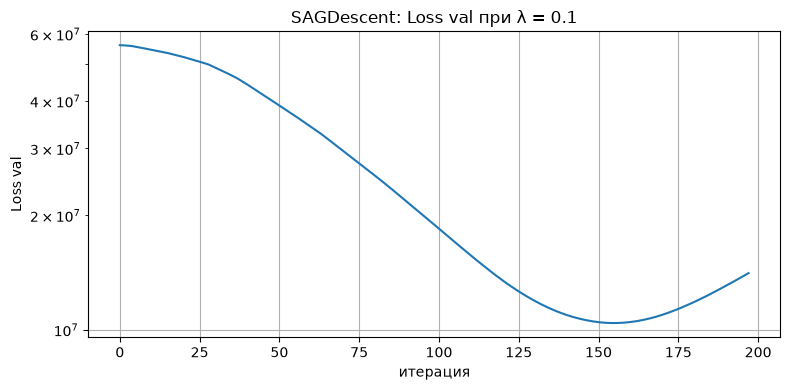

In [16]:
print_summary("SAGDescent", sag_best, X_train, y_train, X_test, y_test)
plot_val_history("SAGDescent", sag_best)

#### 12. Исследование MomentumDescent

1. Для каждого шага lyamda в логарифмической сетке: 10^-5, … , 1:

обучите MomentumDescent с шагом lyamda на train, вычисляем R^2_train и Loss_train;

протестируйте MomentumDescent с шагом lyamda на val, вычисляем Loss_val.

2. Найдите наилучший шаг lyamda по минимальному Loss_val.

In [17]:
class MomentumDescent(BaseLinearDescent):
    alpha: float = 0.9
    _momentum: Array

    def _step(self, X: Array, y: Array, w: Array, k: int, rng: np.random.Generator) -> Array:
        if k == 0:
            self._momentum = np.zeros(X.shape[1], dtype=np.float64)
        self._momentum = self.alpha * self._momentum + self._lr(k) * mse_gradient(X, y, w)
        return w - self._momentum


momentum_table, momentum_best = tune_lambda(MomentumDescent, X_train, y_train, X_val, y_val)
momentum_table

,lambda,loss_train,r2_train,loss_val,n_iter
0,0.00001,1.178431e+08,-0.781649,5.606228e+07,2
1,0.00010,6.312464e+07,0.045630,2.130342e+07,2539
2,0.00100,2.430618e+07,0.632519,9.257439e+06,1128
3,0.01000,2.053816e+07,0.689487,1.151033e+07,327
4,0.10000,1.904218e+07,0.712105,1.258916e+07,62
5,1.00000,1.372221e+07,0.792536,1.514841e+07,137
6,10.00000,inf,-inf,4.345250e+305,208
7,100.00000,inf,-inf,inf,72


#### 13. Тестирование MomentumDescent с лучшим шагом

Выведите (R_test)^2 и Loss_test.

In [18]:
momentum_loss_test, momentum_r2_test = score(momentum_best, X_test, y_test)
print(f"Лучший шаг: {momentum_best.lambda_:g}")
print(f"Loss test:  {momentum_loss_test:.2f}")
print(f"R^2 test:   {momentum_r2_test:.4f}")

Лучший шаг: 0.001
Loss test:  19932914.29
R^2 test:   0.6685


#### 14. Вывод по MomentumDescent

1. Выведите на экран: лучший шаг, loss_train (для лучшего шага), loss_test, r^2_train (для лучшего шага), число итераций на val;

2. Отобразите график зависимости Loss_val для лучшего шага от числа итераций.

MomentumDescent
  лучший шаг: 0.001
  Loss train: 24306184.47
  Loss test:  19932914.29
  R^2 train:  0.6325
  R^2 test:   0.6685
  итераций:   1128


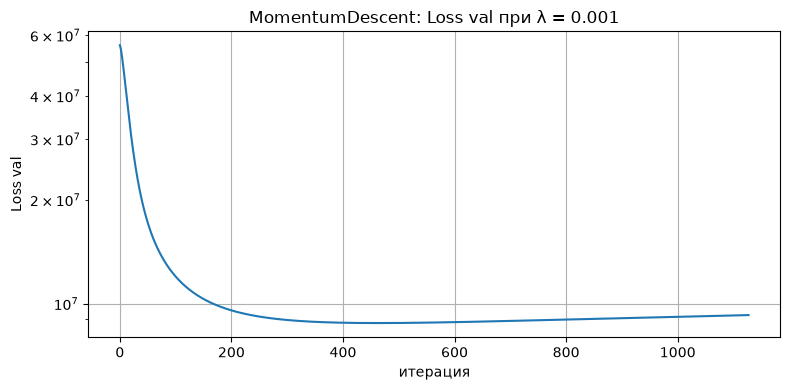

In [19]:
print_summary("MomentumDescent", momentum_best, X_train, y_train, X_test, y_test)
plot_val_history("MomentumDescent", momentum_best)

#### 15. Исследование Adam

1. Для каждого шага lyamda в логарифмической сетке: 10^-5, … , 1:

обучите Adam с шагом lyamda на train, вычисляем R^2_train и Loss_train;

протестируйте Adam с шагом lyamda на val, вычисляем Loss_val.

2. Найдите наилучший шаг lyamda по минимальному Loss_val.

In [20]:
class Adam(BaseLinearDescent):
    beta1: float = 0.9
    beta2: float = 0.999
    eps: float = 1e-8
    _m: Array
    _v: Array

    def _step(self, X: Array, y: Array, w: Array, k: int, rng: np.random.Generator) -> Array:
        if k == 0:
            self._m = np.zeros(X.shape[1], dtype=np.float64)
            self._v = np.zeros(X.shape[1], dtype=np.float64)
        grad = mse_gradient(X, y, w)
        self._m = self.beta1 * self._m + (1.0 - self.beta1) * grad
        self._v = self.beta2 * self._v + (1.0 - self.beta2) * grad**2
        m_hat = self._m / (1.0 - self.beta1 ** (k + 1))
        v_hat = self._v / (1.0 - self.beta2 ** (k + 1))
        return w - self._lr(k) * m_hat / (np.sqrt(v_hat) + self.eps)


adam_table, adam_best = tune_lambda(Adam, X_train, y_train, X_val, y_val)
adam_table

,lambda,loss_train,r2_train,loss_val,n_iter
0,0.00001,1.178521e+08,-0.781784,5.606854e+07,2
1,0.00010,1.178521e+08,-0.781784,5.606853e+07,2
2,0.00100,1.178519e+08,-0.781782,5.606845e+07,2
3,0.01000,1.178508e+08,-0.781765,5.606765e+07,2
4,0.10000,1.178306e+08,-0.781458,5.605327e+07,3
5,1.00000,1.153525e+08,-0.743993,5.430012e+07,116
6,10.00000,4.243007e+07,0.358508,1.162123e+07,3000
7,100.00000,1.435408e+07,0.782983,1.500573e+07,1226


#### 16. Тестирование Adam с лучшим шагом

Выведите (R_test)^2 и Loss_test.

In [21]:
adam_loss_test, adam_r2_test = score(adam_best, X_test, y_test)
print(f"Лучший шаг: {adam_best.lambda_:g}")
print(f"Loss test:  {adam_loss_test:.2f}")
print(f"R^2 test:   {adam_r2_test:.4f}")

Лучший шаг: 10
Loss test:  38926963.13
R^2 test:   0.3526


#### 17. Вывод по Adam

1. Выведите на экран: лучший шаг, loss_train (для лучшего шага), loss_test, r^2_train (для лучшего шага), число итераций на val;

2. Отобразите график зависимости Loss_val для лучшего шага от числа итераций.

Adam
  лучший шаг: 10
  Loss train: 42430072.63
  Loss test:  38926963.13
  R^2 train:  0.3585
  R^2 test:   0.3526
  итераций:   3000


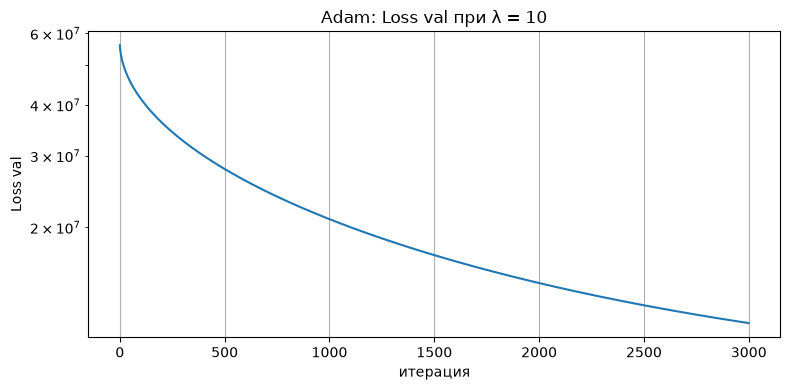

In [22]:
print_summary("Adam", adam_best, X_train, y_train, X_test, y_test)
plot_val_history("Adam", adam_best)

#### 18. Постройте сравнительную таблицу методов

Таблица показана в лекции (таб. 2)

In [23]:
best_models: dict[str, BaseLinearDescent] = {
    "VanillaGradientDescent": vanilla_best,
    "StochasticGradientDescent": sgd_best,
    "SAGDescent": sag_best,
    "MomentumDescent": momentum_best,
    "Adam": adam_best,
}

summary = pd.DataFrame(
    [collect_metrics(model, X_train, y_train, X_test, y_test) for model in best_models.values()],
    index=list(best_models),
)
summary

,lambda,loss_train,loss_test,r2_train,r2_test,n_iter
VanillaGradientDescent,0.010,2.431792e+07,1.996881e+07,0.632342,0.667898,1156
StochasticGradientDescent,0.010,3.642642e+07,3.161736e+07,0.449276,0.474171,181
SAGDescent,0.100,2.975755e+07,2.672422e+07,0.550101,0.555549,198
MomentumDescent,0.001,2.430618e+07,1.993291e+07,0.632519,0.668495,1128
Adam,10.000,4.243007e+07,3.892696e+07,0.358508,0.352605,3000


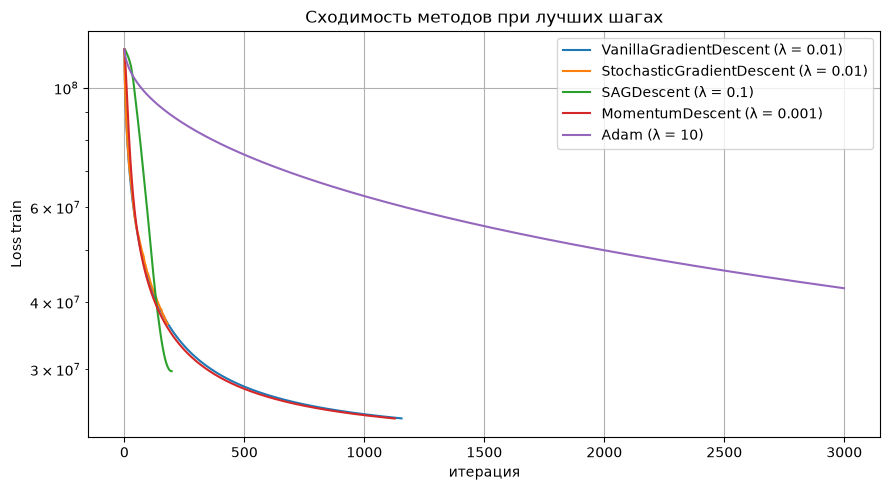

In [24]:
def plot_train_convergence(models: dict[str, BaseLinearDescent]) -> None:
    plt.figure(figsize=(9, 5))  # type: ignore
    for name, model in models.items():
        plt.plot(model.train_loss_history, label=f"{name} (λ = {model.lambda_:g})")
    plt.yscale("log")
    plt.title("Сходимость методов при лучших шагах")
    plt.xlabel("итерация")
    plt.ylabel("Loss train")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()  # type: ignore


plot_train_convergence(best_models)

#### 19. Сделайте вывод о том, какой метод и какой шаг в итоге самые оптимальные, обратите внимание на R^2, подумайте на что он влияет.

**Ответ:** По результатам эксперимента лучше всего себя показал MomentumDescent с `lambda = 0.001`: у него получился минимальный `Loss_test` — `1.99·10⁷`, а `R²_test` составил `0.668`. При этом VanillaGradientDescent с `lambda = 0.01` показывает практически такой же результат (`R²_test = 0.668`), поэтому заметной разницы по качеству между ними нет.

Значение `R² = 0.67` означает, что модель объясняет примерно 67% разброса цен с помощью используемых признаков. Оставшаяся часть может быть связана с нелинейными зависимостями, шумом и признаками, которых нет в данных в `train`. У VanillaGradientDescent и MomentumDescent значение `R²_test` немного выше, чем `R²_train`, поэтому явных признаков переобучения здесь не наблюдается.

У Adam результат заметно хуже (`R²_test = 0.35`). мб, за 3000 итераций алгоритм не успел сойтись.

SGD с `lambda = 0.01` и SAG с `lambda = 0.1` сходятся примерно за 180–200 итераций, но качество на тестовой выборке у них ниже: `R²_test` около `0.47` и `0.56`.

В итоге для данной задачи я бы выбрал MomentumDescent с `lambda = 0.001` и VanillaGradientDescent.